In [186]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data, save_fig

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader
from attention_nn.model import create_model

apply_general_styles()

# Test scales

In [2]:
# Define configuration

config = {
    'd_model': 10000,
    'dataset_size': 100,
    'train_fraction': 0.9,
    'batch_size': 1,
    'seq_len': 124,
    'dropout': 0.0,
    'rank': 102,
    'num_epochs': 5,
    'lr': 1.0,
    'datasource': 'roneneldan/TinyStories',
    'freeze_embeddings': False,
    'freeze_attention': False,
    'random_positional_encoding': False,
    'skip_residual': False,
    'amplitude': 1.0,
    'sigma': 1,
}

config['amplitude'] = 0.0#config['amplitude']/np.sqrt(config['d_model'])  # Scale amplitude with sqrt(d_model)

In [3]:
# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
config['vocab_size'] = tokenizer.get_vocab_size()
print(f'Vocabulary size = {config["vocab_size"]}. Maximum entropy per token = {np.log(config["vocab_size"]):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

# Set device and build model
model , device = create_model(config)
print(f'Model built on device: {device}')

Preparing data loaders...


Min sequence length = 94
Max sequence length = 267
Vocabulary size = 1019. Maximum entropy per token = 6.9266 nats.
Model built on device: cuda


In [4]:
for batch in train_dataloader:
    input = batch['input'].to(device) # (batch_size, seq_len)
    label = batch['label'].to(device) # (batch_size, seq_len)
    mask = batch['attention_mask'].to(device) # (batch_size, seq_len, seq_len)

    e = model.input_embeddings(input)  # (batch, seq_len, d_model)
    xp = model.positional_encoding(e)  # (batch, seq_len, d_model)
    proj_left = model.attention_layer.Wq(xp)   # (batch, seq_len, rank) - cheaper!
    proj_right = model.attention_layer.Wk(xp)  # (batch, seq_len, rank)
    dot  = proj_left @ proj_right.transpose(-2, -1)/  (np.sqrt(model.rank))
    A =  torch.softmax(dot.masked_fill(mask==0,-1e9), dim=-1)
    # A = model.attention_layer.attention_probabilities(xp,mask)
    xa = A @ xp
    xo = xa + xp

    break


np.float32(0.023341483)

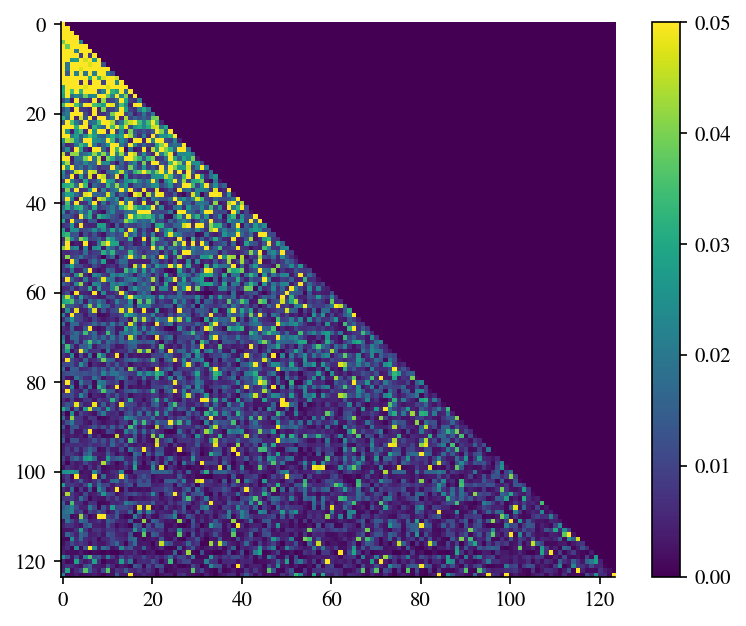

In [7]:
a = (A[0]).cpu().detach().numpy() 
plt.imshow(a,vmax=0.05)
plt.colorbar()

a.std()

# Plots measurements

In [229]:
d_model = 1024
dataset_size = 10000
seq_len = 256
batch_size = 64
lr = 0.001
rank = None
freeze_embeddings = False
freeze_attention = False
skip_residual = False
random_positional_encoding = True


fix_names = ['rank','d_model','seq_len','dataset_size','random_positional_encoding']#[:-1]
var_names = ['batch_size','lr','freeze_embeddings','freeze_attention','skip_residual']
params = make_params_dict(fix_names , var_names)


summary = load_data('summary',experiment_name='new_measurements', params=params)

for key in summary.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary[key].shape}')

        
# File saved with pickle.dump on /u/c/cerazova/Transformers/data/new_measurements/d_model512_dataset_size10000_rank64_seq_len256 as summary_batch_size64_freeze_attentionFalse_freeze_embeddingsFalse_lr0.001_skip_residualFalse.pkl


File summary_batch_size64_freeze_attentionFalse_freeze_embeddingsFalse_lr0.001_skip_residualFalse.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_measurements/d_model1024_dataset_size10000_random_positional_encodingTrue_rankNone_seq_len256
train_loss: (212,)
val_loss: (212,)
entropy: (212, 5)
part_ratio: (212, 5)
sequence_fractions: (5,)
evaluation_steps: (212,)
vocab_size: ()
embedd_eigvals: (212, 1024)
W_eigvals: (212, 1024)
attention_patterns: (212, 256, 256)
norm_W: (212,)
positional_encodings: (212, 256, 1024)
grad_embedding: (212,)
grad_W: (212,)


In [230]:
step = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
embedd_top_tokens = summary['embedd_top_tokens']
print(f'Seq fractions: {sequence_fractions}')
k = 4
print(f'Tokens aligned with {k}-th top eigvector of embedding covariance matrix:')
for i , toks in enumerate(embedd_top_tokens[::3]):
    print(f'Step {step[::3][i]}: {toks[k]}')
# print(f'Embedd top tokens shape: {embedd_top_tokens}')


Seq fractions: [0.2 0.4 0.6 0.8 1. ]
Tokens aligned with 4-th top eigvector of embedding covariance matrix:
Step 0: ['awaited', 'realized', ',', 'is', 'Hope', 'accomplish', 'caterpillar', 'fish', 'sample', 'hideout', 'replaced', 'crickets', 'balcony', 'softens', 'flower', 'depths', 'studied', 'cost', 'health', 'neither', 'minding', 'your', 'shelter', 'gear', 'single', 'vibrate', 'Dusty', 'slapped', 'Kevin', 'comforted']
Step 30: ['language', 'rains', 'shade', 'art', 'poles', 'Dolly', 'tunes', 'Meadow', 'Moving', '10', 'bin', 'Cop', 'original', 'appears', 'bus', 'tagged', 'guys', 'squirrel', 'thumbs', 'tanks', 'tripped', 'grassy', 'thrilled', 'cleaned', 'riding', 'accomplish', 'beloved', 'earn', 'Time', 'festival']
Step 60: ['Remember', 'appears', 'shade', 'squeal', 'beeps', 'Cop', 'leaking', 'garden', 'original', 'language', 'tails', 'admitted', '10', 'Look', 'decide', 'look', 'Moving', 'happen', 'Charles', 'beloved', 'flood', 'hopscotch', 'admired', 'worry', 'blew', 'slower', 'Nick', 

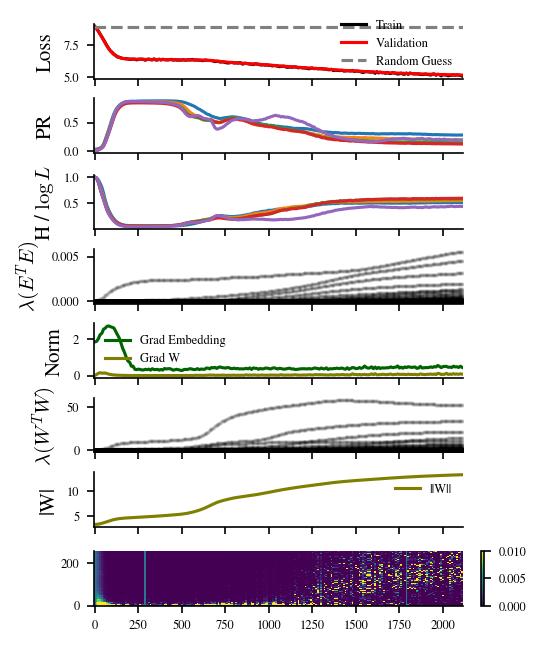

In [211]:


set_font_sizes(conf='tight')
i_seq_frac = -1  # index of sequence fraction to plot
fig , axes = create_fig(nrows=8,h=1.2)

ax = axes[0]
ax.plot(step,summary['train_loss'], label='Train', color='k')
ax.plot(step,summary['val_loss'], label='Validation', color='r')
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label='Random Guess')
ax.set_ylabel('Loss')
ax.legend(frameon=False)


ax = axes[1]
ax.plot(step, summary['part_ratio'], label='Validation')
ax.set_ylabel('PR')
# ax.legend(frameon=False)


ax = axes[2]
ax.plot(step, summary['entropy'], label='Validation')
ax.set_ylabel(r'H / $\log L$')
# ax.legend(frameon=False)    



ax = axes[3]
for i , t in enumerate(step):
    ax.scatter([t]*d_model,summary['embedd_eigvals'][i],s=1,alpha=0.2,color='k')

ax.set_ylabel(r'$\lambda(E^T E)$')
# ax.set_yscale('log')

ax = axes[4]
ax.plot(step, summary['grad_embedding'],label='Grad Embedding', color='darkgreen')
if rank is not None:
    print(rank)
    ax.plot(step, summary['grad_Wq'],label='Grad Wq', color='olive')
    ax.plot(step, summary['grad_Wk'],label='Grad Wk', color='darkblue')
else:
    ax.plot(step,summary['grad_W'],label='Grad W', color='olive')
ax.set_ylabel('Norm')
ax.legend(frameon=False)
# ax.set_yscale('log')

ax = axes[5]
m = rank if rank is not None else d_model
for i , t in enumerate(step):
    ax.scatter([t]*m,summary['W_eigvals'][i],s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(W^T W)$')
# ax.set_yscale('log')

ax = axes[6]
ax.plot(step, summary['norm_W'] , label='||W||', color='olive')
ax.set_ylabel('|W|')
ax.legend(frameon=False)


ax = axes[7]

attention_patterns = summary['attention_patterns']  # (num_steps, seq_len, seq_len)
i_seq = seq_len//1 - 1

# ax.set_xlim(0,200)

mesh = ax.pcolormesh(step, np.arange(seq_len), attention_patterns[:, i_seq].T, shading='auto',vmax=0.01)
plt.colorbar(mesh, ax=ax)

[  0  27  54  81 108 135 162 189]
0 0
1 27
2 54
3 81
4 108
5 135
6 162
7 189
8


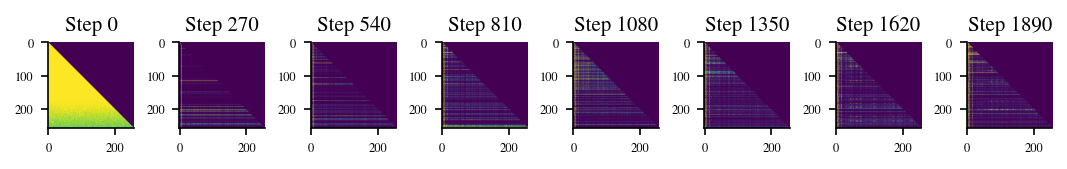

In [124]:

fig , axes = create_fig(ncols=8,w=2)

idx = np.arange(0,len(step),max(1,len(step)//8 +1))
print(idx)
for i , t in enumerate(idx):
    ax = axes[i]
    print(i,t)
    ax.imshow(attention_patterns[t],vmax=0.005)
    ax.set_title(f'Step {step[t]}')
print(len(idx))

# Polished Plot

Figure saved on /u/c/cerazova/Transformers/plots as measures_d_model1024_freeze_attentionFalse_freeze_embeddingsFalse_lr0.001_random_positional_encodingTrue_seq_len256_skip_residualFalse.png


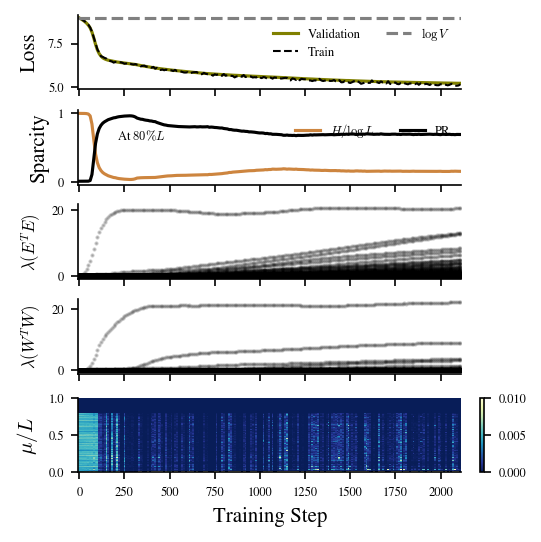

In [231]:
step = summary['evaluation_steps']
vocab_size = int(summary['vocab_size'])
sequence_fractions = summary['sequence_fractions']
i_seq_frac = 3
set_font_sizes(conf='tight')

fig , axes = create_fig(nrows=5,h=1)

ax = axes[0]
ax.plot(step,summary['val_loss'], label='Validation', color='olive',ls='-')
ax.plot(step,summary['train_loss'], label='Train', color='k',ls='--',lw=1)
ax.axhline(np.log(vocab_size), color='gray', linestyle='--', label=r'$\log V$')
ax.set_ylabel('Loss')
ax.legend(frameon=False,ncols=2)

ax = axes[1]
ax.plot(step, summary['entropy'][:,i_seq_frac], label=r'$H/\log L$', color='peru',ls='-')
ax.plot(step, summary['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
ax.set_ylabel('Sparcity')
ax.legend(frameon=False,ncols=2,loc='upper right')
ax.text(x=0.1, y=0.6, 
        s=fr'At ${ 100* sequence_fractions[i_seq_frac]:.0f} \% L$',
        transform=ax.transAxes,
        fontsize=FONTSIZES['xs'])

ax = axes[2]
for i , t in enumerate(step):
    ax.scatter([t]*d_model,vocab_size*summary['embedd_eigvals'][i],s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(E^T E)$',size=FONTSIZES['s'])

ax = axes[3]
for i , t in enumerate(step):
    ax.scatter([t]*d_model,summary['W_eigvals'][i],s=1,alpha=0.2,color='k')
ax.set_ylabel(r'$\lambda(W^T W)$',size=FONTSIZES['s'])


ax = axes[4]

attention_patterns = summary['attention_patterns']  # (num_steps, seq_len, seq_len)
i_seq = int(sequence_fractions[i_seq_frac]*seq_len) - 1
mesh = ax.pcolormesh(step, np.arange(seq_len)/seq_len, attention_patterns[:, i_seq].T,cmap='YlGnBu_r',vmax=0.01)
plt.colorbar(mesh, ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel(r'$\mu / L$')
ax.set_xlabel('Training Step')




names = ['d_model','seq_len','lr','freeze_embeddings','freeze_attention','skip_residual','random_positional_encoding']
params = make_params_dict(names)
save_fig(fig,'measures',params=params)

In [208]:
x = 'batch_size64_d_model1024_dataset_size10000_freeze_attentionFalse_freeze_embeddingsTrue_lr0.001_random_positional_encodingTrue_seq_len256_skip_residualFalse'
len(x)

155